In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("..\..\Datasets\IMDB_dataset.csv")
df.head(10)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
6,I sure would like to see a resurrection of a u...,positive
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative
9,If you like original gut wrenching laughter yo...,positive


In [3]:
df.sample(10)

,review,sentiment
46063,Shinjuku Triad Society: Chinese Mafia Wars is ...,positive
23168,"This is one of those ""family"" movies that I ca...",negative
31208,"As with FOOTPRINTS (1975), I became aware of t...",positive
18747,What a total lump of poopoo this was! You've g...,negative
39458,"Ah, the infamous ""Guinea Pig"" series...I hones...",negative
7561,I've read some of the comments about this film...,negative
13447,Several story lines are interwoven here around...,positive
3851,Garlin did a great job. Nice concept well exec...,positive
23524,This low budget B horror's plot comes with all...,negative
68,I'm not sure why the producers needed to trade...,negative


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
# changing the ojbect to lowercase and remove the sepcial characters
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()  # ' text '
    return text

df['review'] = df['review'].apply(preprocess_text)
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive


In [6]:
nltk.download('stopwords')  # downloading the nltk stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aravi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
stop_words = set(stopwords.words('english'))
keep_words = {
    'not', 'no', 'nor', 'don', "don't", 'didn', "didn't", 'doesn', "doesn't",
    'isn', "isn't", 'wasn', "wasn't", 'weren', "weren't", 'aren', "aren't",
    'couldn', "couldn't", 'shouldn', "shouldn't", 'wouldn', "wouldn't",
    'won', "won't", 'hasn', "hasn't", 'hadn', "hadn't", 'haven', "haven't",
    'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'mightn', "mightn't",
    'ma'
}

stop_words = stop_words - keep_words

In [8]:
# function to remove stopwords
def remove_stopwords(text):
    words = re.findall(r'\w+', text.lower()) # tokenize text
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

# apply stopword removal
df['review'] = df['review'].apply(remove_stopwords)
df.head()

,review,sentiment
0,one reviewers mentioned watching oz episode yo...,positive
1,wonderful little production filming technique ...,positive
2,thought wonderful way spend time hot summer we...,positive
3,basically theres family little boy jake thinks...,negative
4,petter matteis love time money visually stunni...,positive


In [9]:
df['sentiment'].unique()

array(['positive', 'negative'], dtype=object)

In [10]:
# change the sentiment to 1 and 0
df['sentiment'] = df['sentiment'].map({'positive' : 1, "negative" : 0})
df.head()

,review,sentiment
0,one reviewers mentioned watching oz episode yo...,1
1,wonderful little production filming technique ...,1
2,thought wonderful way spend time hot summer we...,1
3,basically theres family little boy jake thinks...,0
4,petter matteis love time money visually stunni...,1


In [11]:
# apply TF-IDF Vectorization with a limited feature size to reduce memory usage
vectorizer = TfidfVectorizer(
    max_features= 10000,
    min_df=5,
    max_df=0.8,
    ngram_range=(1,2)
)
X = vectorizer.fit_transform(df['review'])

In [12]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4647160 stored elements and shape (50000, 10000)>
  Coords	Values
  (0, 6288)	0.021239415365050994
  (0, 7434)	0.07530600825273337
  (0, 5406)	0.06571610202871687
  (0, 9593)	0.07721391291858262
  (0, 6461)	0.4438737674478477
  (0, 2663)	0.11429676765770856
  (0, 9960)	0.054405726406328514
  (0, 4089)	0.08305209478082806
  (0, 7463)	0.08646769108723934
  (0, 2782)	0.05746907219309365
  (0, 3892)	0.0575356315038815
  (0, 3259)	0.06412932099403731
  (0, 8862)	0.03881202702247508
  (0, 8500)	0.16640920275070886
  (0, 1011)	0.09272921104005004
  (0, 7700)	0.038161111950818526
  (0, 9447)	0.23570208170187648
  (0, 7891)	0.04747759405011315
  (0, 9811)	0.05894199297489845
  (0, 3643)	0.03784385769692646
  (0, 9164)	0.07324473962151125
  (0, 6063)	0.061048770067838626
  (0, 7993)	0.12126946603702259
  (0, 3956)	0.09304699539261918
  (0, 7013)	0.07873175961937721
  :	:
  (49999, 4258)	0.14719137732525983
  (49999, 2945)	0.0930360561

In [13]:
x = X
y = df['sentiment']

# split the data into training and testing set

X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
# train a random forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Accuracy: 85.57%

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.87      0.86      5000
           1       0.86      0.84      0.85      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



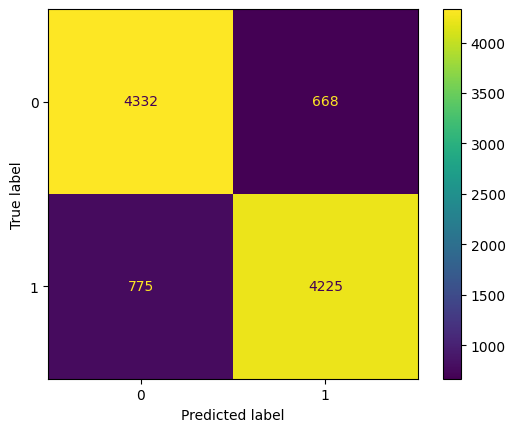

In [15]:
# predict the sentiment of the test set
y_pred = clf.predict(X_test)

# calculate the accuracy of the model 
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}%".format(accuracy*100))

# classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

#Confusion matrix display
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

In [16]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)

Accuracy: 89.54%

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.89      0.89      5000
           1       0.89      0.90      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



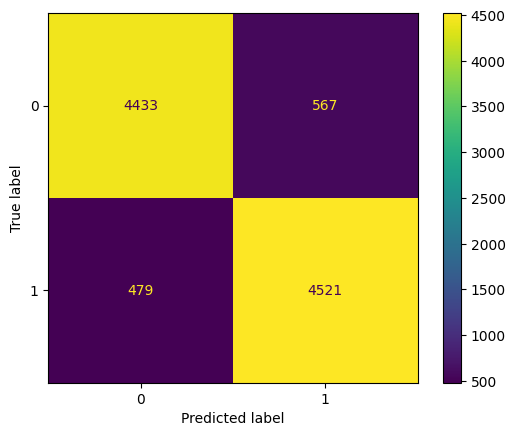

In [17]:
clf.fit(X_train, y_train)

# predict the sentiment of the test set
y_pred = clf.predict(X_test)

# calculate the accuracy of the model 
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}%".format(accuracy*100))

# classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

#Confusion matrix display
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

In [ ]:
def predict_sentiment(text):
    text = preprocess_text(text)
    text = remove_stopwords(text)
    text_vector = vectorizer.transform([text])
    predicted = clf.predict(text_vector)
    return "Positive" if predicted == 1 else "Negative"

reviews = [
    "Amazing movie with a great storyline!",
    "I am not enjoy this film at all.",
    "It was okay, nothing special"
]

for review in reviews:
    print(f"Review: {review}.\nPredicted Sentiment: {predict_sentiment(review)}")

Review: Amazing movie with a great storyline!.
Predicted Sentiment: Positive
Review: I didn't enjoy this film at all..
Predicted Sentiment: Positive
Review: It was okay, nothing special.
Predicted Sentiment: Negative
